In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

# Load the dataset and convert it to a pandas DataFrame
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean the date and time columns
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_posted_date'] = df['job_posted_date'].dt.tz_localize('UTC')
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else [skill_list])

In [2]:
# Analyzing the skills required for the top 3 jobs in the India
df_India = df[df['job_country'] == 'India'].copy()

df_skills = df_India.copy()
df_skills = df_skills.explode('job_skills')
skills_counts = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_counts = skills_counts.reset_index(name='skill_count')
df_skills_counts.sort_values(by='skill_count', ascending=False, inplace=True)

# Calculating the percentage of each skill for each job title
df_job_counts = df_India['job_title_short'].value_counts().reset_index(name='job_total')
df_skills_counts_percent = pd.merge(df_skills_counts, df_job_counts, how='left', on='job_title_short')
df_skills_counts_percent['skill_percentage'] = ((df_skills_counts_percent['skill_count']) / (df_skills_counts_percent['job_total'])) * 100

# Focusing on the top 3 job titles in India, data obtained from the previous analysis (1_Exploratory_Data_Analysis.ipynb)
job_titles = sorted(df_skills_counts['job_title_short'].unique().tolist()[:3])

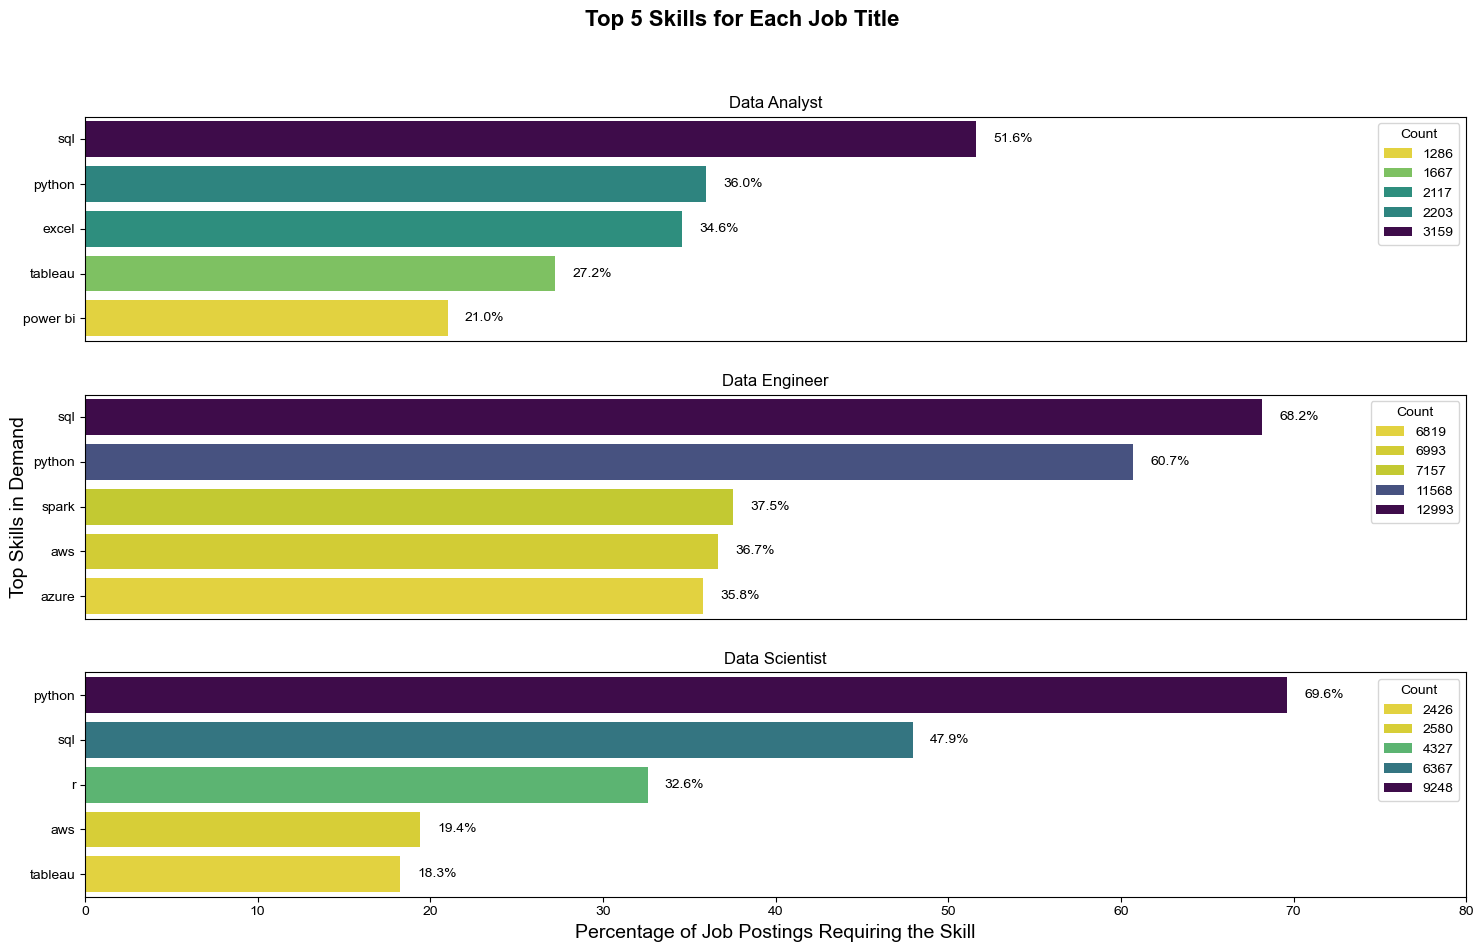

In [3]:
# Creating subplots for each of the top 3 job titles
fig, ax = plt.subplots(len(job_titles), 1, figsize=(15, 10))

# Plotting the top 5 skills for each job title with percentage labels
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_counts_percent[df_skills_counts_percent['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='viridis_r')
    ax[i].set_title(f'{job_title}')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 80)
    ax[i].legend(title='Count', loc='upper right')
    # Adding percentage labels to the bars
    for j, (skill_percentage, skill_count) in enumerate(zip(df_plot['skill_percentage'], df_plot['skill_count'])):
        ax[i].text(skill_percentage + 1, j, f'{skill_percentage:.1f}%', va='center')
    # Setting the x-axis label for the last subplot
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

# Setting the overall title and adjusting layout
fig.suptitle('Top 5 Skills for Each Job Title', fontsize=16, fontweight='bold')
# Setting y-axis labels for the middle subplot(s)
if len(job_titles)%2 != 0:
    ax[int(((len(job_titles)+1)/2)-1)].set_ylabel('Top Skills in Demand', fontsize=14)
else:
    ax[int((len(job_titles)/2)-1)].set_ylabel('Skills', fontsize=14)
ax[len(job_titles)-1].set_xlabel('Percentage of Job Postings Requiring the Skill', fontsize=14)
sns.set_theme(style="whitegrid")
fig.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2)
plt.show()